In [37]:
import pandas as pd
df = pd.read_csv('/content/AgriPulse_India_2000_2026(in) (1).csv')
df.head()

,AgriPulse_India_2000_2026,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ID,State_Region,YEAR,CROP-TYPE,SOIL_TYPE,SOIL_PH,FERTILIZER(KG/HA),PESTICIDE(KG/HA),AVG_YIELD,TEMP,RAIN
2,1,Punjab,2000,Wheat,Alluvial_Soil,7.2,180,2.4,62.5,24.5,1200
3,2,Haryana,2001,Rice,Alluvial_Soil,7.1,175,2.2,51.8,26.8,850
4,3,UP,2002,Sugarcane,Alluvial_Loam,6.8,230,3.5,890,22.1,1450


In [38]:
print(df.isnull().sum())

AgriPulse_India_2000_2026    1
Unnamed: 1                   1
Unnamed: 2                   1
Unnamed: 3                   1
Unnamed: 4                   1
Unnamed: 5                   1
Unnamed: 6                   1
Unnamed: 7                   1
Unnamed: 8                   1
Unnamed: 9                   1
Unnamed: 10                  1
dtype: int64


In [39]:
# 1. Pehli khali line ko skip karke phir se load karein
df = pd.read_csv('/content/AgriPulse_India_2000_2026(in) (1).csv', skiprows=1)

# 2. Ab check karein ki null values khatam hui ya nahi
print("Ab missing values kitni hain:")
print(df.isnull().sum())

# 3. Sahi table dekhne ke liye
df.head()

Ab missing values kitni hain:
Unnamed: 0     0
Unnamed: 1     0
Unnamed: 2     0
Unnamed: 3     0
Unnamed: 4     0
Unnamed: 5     0
Unnamed: 6     0
Unnamed: 7     0
Unnamed: 8     0
Unnamed: 9     0
Unnamed: 10    0
dtype: int64


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,ID,State_Region,YEAR,CROP-TYPE,SOIL_TYPE,SOIL_PH,FERTILIZER(KG/HA),PESTICIDE(KG/HA),AVG_YIELD,TEMP,RAIN
1,1,Punjab,2000,Wheat,Alluvial_Soil,7.2,180,2.4,62.5,24.5,1200
2,2,Haryana,2001,Rice,Alluvial_Soil,7.1,175,2.2,51.8,26.8,850
3,3,UP,2002,Sugarcane,Alluvial_Loam,6.8,230,3.5,890,22.1,1450
4,4,Maharashtra,2003,Cotton,Black_Regur,7.8,115,1.6,24.2,28.3,600


In [40]:
# Headers ko sahi jagah lane ke liye
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

# Ab dekhiye jaadu!
df.head()

,ID,State_Region,YEAR,CROP-TYPE,SOIL_TYPE,SOIL_PH,FERTILIZER(KG/HA),PESTICIDE(KG/HA),AVG_YIELD,TEMP,RAIN
0,1,Punjab,2000,Wheat,Alluvial_Soil,7.2,180,2.4,62.5,24.5,1200
1,2,Haryana,2001,Rice,Alluvial_Soil,7.1,175,2.2,51.8,26.8,850
2,3,UP,2002,Sugarcane,Alluvial_Loam,6.8,230,3.5,890,22.1,1450
3,4,Maharashtra,2003,Cotton,Black_Regur,7.8,115,1.6,24.2,28.3,600
4,5,Gujarat,2004,Groundnut,Sandy_Loam,7.4,100,0.8,28.5,19.5,950


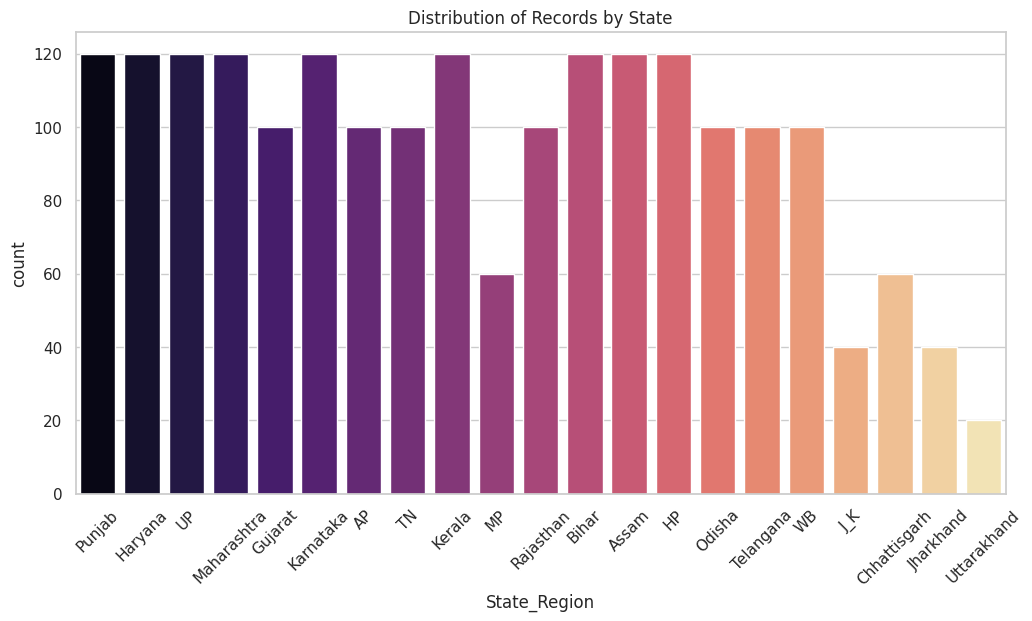

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph ka style aur size set karein
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid")

# Ek bar chart banayein jo dikhayega ki har State ke kitne records hain
sns.countplot(data=df, x='State_Region', hue='State_Region', palette='magma', legend=False)

plt.title('Distribution of Records by State')
plt.xticks(rotation=45) # Taaki States ke naam saaf dikhein
plt.show()

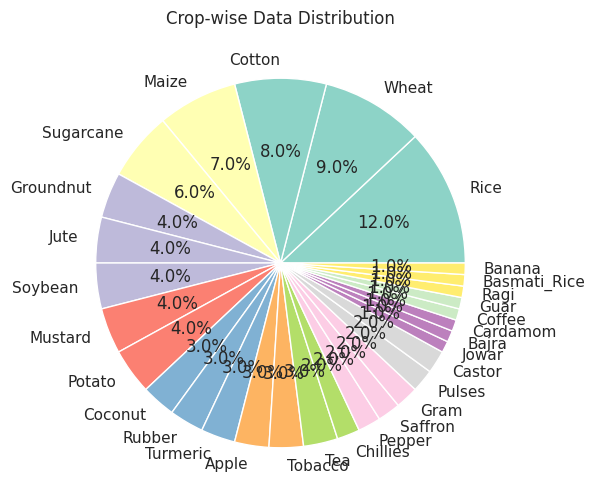

In [42]:
# Har crop kitni baar aaya hai ye dekhne ke liye
plt.figure(figsize=(10,6))

# Pie chart banate hain taaki distribution saaf dikhe
df['CROP-TYPE'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Set3')

plt.title('Crop-wise Data Distribution')
plt.ylabel('') # Takki 'CROP-TYPE' likha hua na aaye
plt.show()

In [46]:
# Production aur Soil pH ke beech ka rishta dekhne ke liye
plt.figure(figsize=(10,6))

# Scatter plot banayein
# Note: Agar aapke production column ka naam alag hai, toh use badal lein
sns.scatterplot(data=df, x='SOIL_PH', y='PRODUCTION', hue='CROP-TYPE', palette='deep')

plt.title('Relationship between Soil pH and Production')
plt.xlabel('Soil pH')
plt.ylabel('Production Amount')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Legend ko bahar rakhne ke liye
plt.show()

ValueError: Could not interpret value `PRODUCTION` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [47]:
# Saare columns ke naam dekhne ke liye
print(df.columns)

Index(['ID', 'State_Region', 'YEAR', 'CROP-TYPE', 'SOIL_TYPE', 'SOIL_PH',
       'FERTILIZER(KG/HA)', 'PESTICIDE(KG/HA)', 'AVG_YIELD', 'TEMP', 'RAIN'],
      dtype='object', name=0)


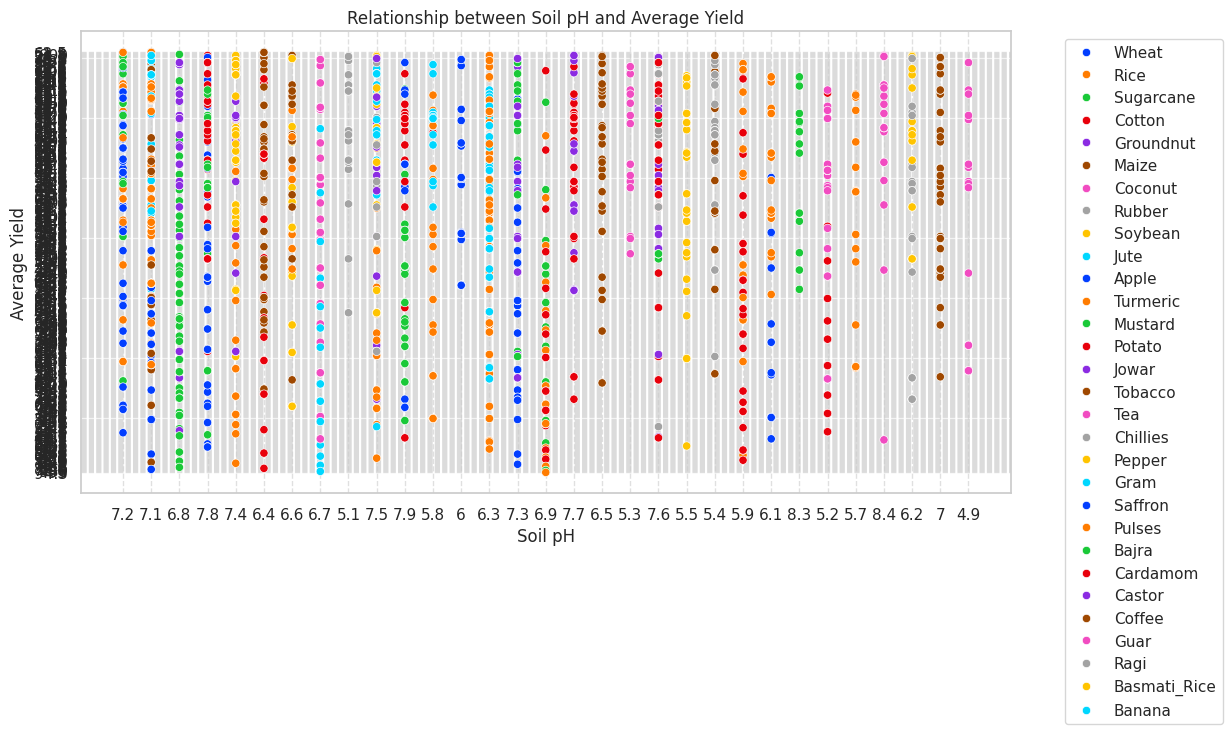

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph ka size set karein
plt.figure(figsize=(12,6))

# Scatter plot: Soil pH aur Average Yield ke beech ka rishta
sns.scatterplot(data=df, x='SOIL_PH', y='AVG_YIELD', hue='CROP-TYPE', palette='bright')

plt.title('Relationship between Soil pH and Average Yield')
plt.xlabel('Soil pH')
plt.ylabel('Average Yield')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Crops ki list side mein dikhegi
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

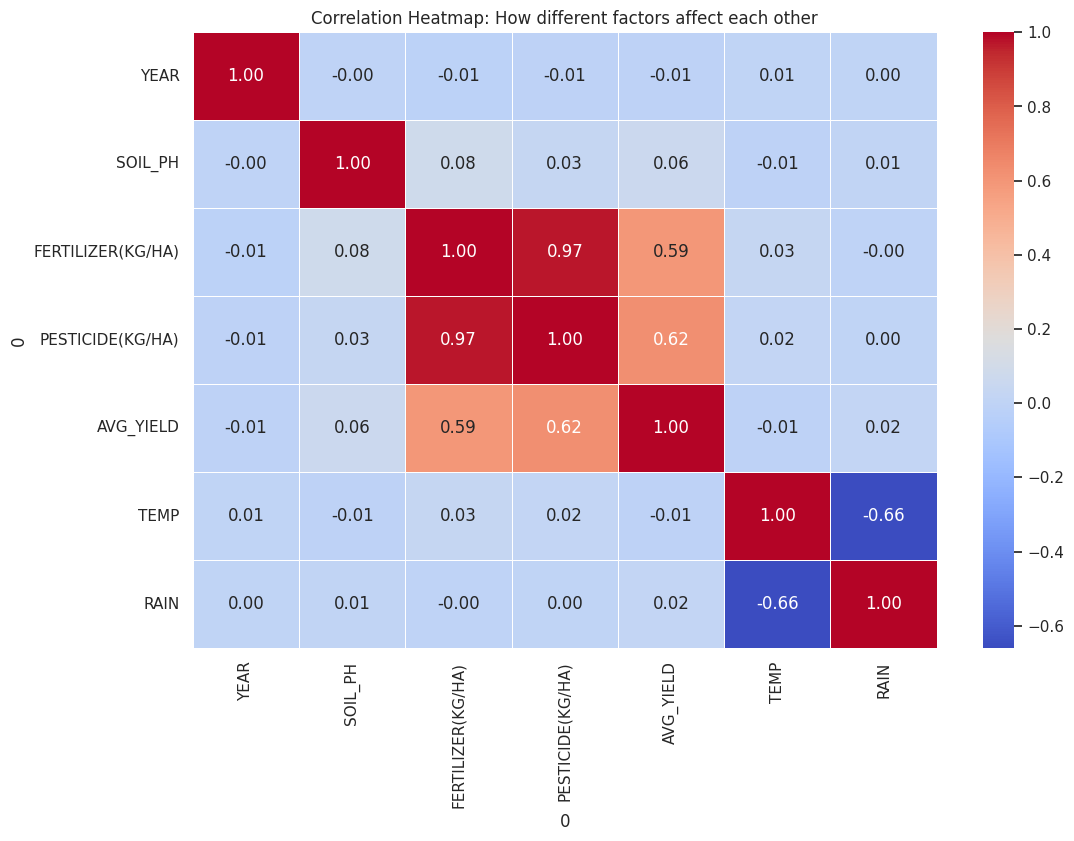

In [52]:
# Sirf numbers wale columns ka aapas mein rishta dekhne ke liye
plt.figure(figsize=(12, 8))

# Correlation nikalna aur Heatmap banana
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: How different factors affect each other')
plt.show()

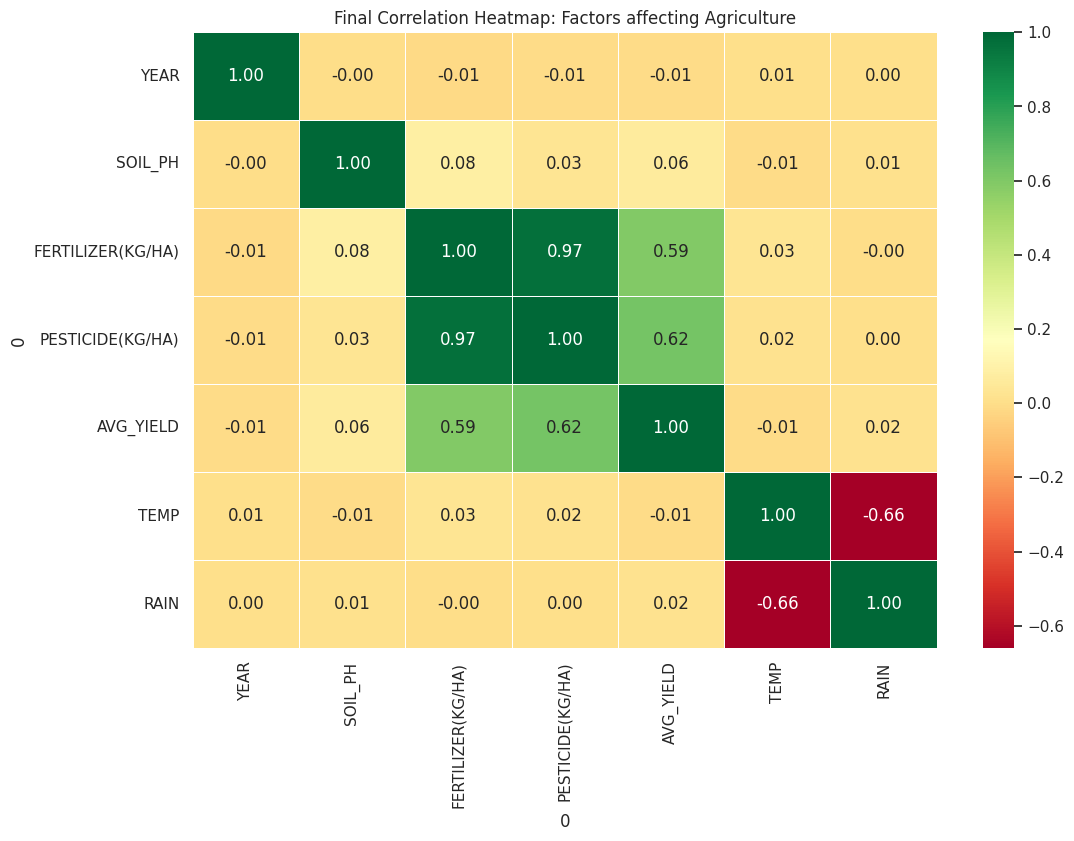

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sabse pehle columns ko numbers mein badalte hain
numeric_cols = ['YEAR', 'SOIL_PH', 'FERTILIZER(KG/HA)', 'PESTICIDE(KG/HA)', 'AVG_YIELD', 'TEMP', 'RAIN']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Ab Heatmap banate hain
plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)

plt.title('Final Correlation Heatmap: Factors affecting Agriculture')
plt.show()

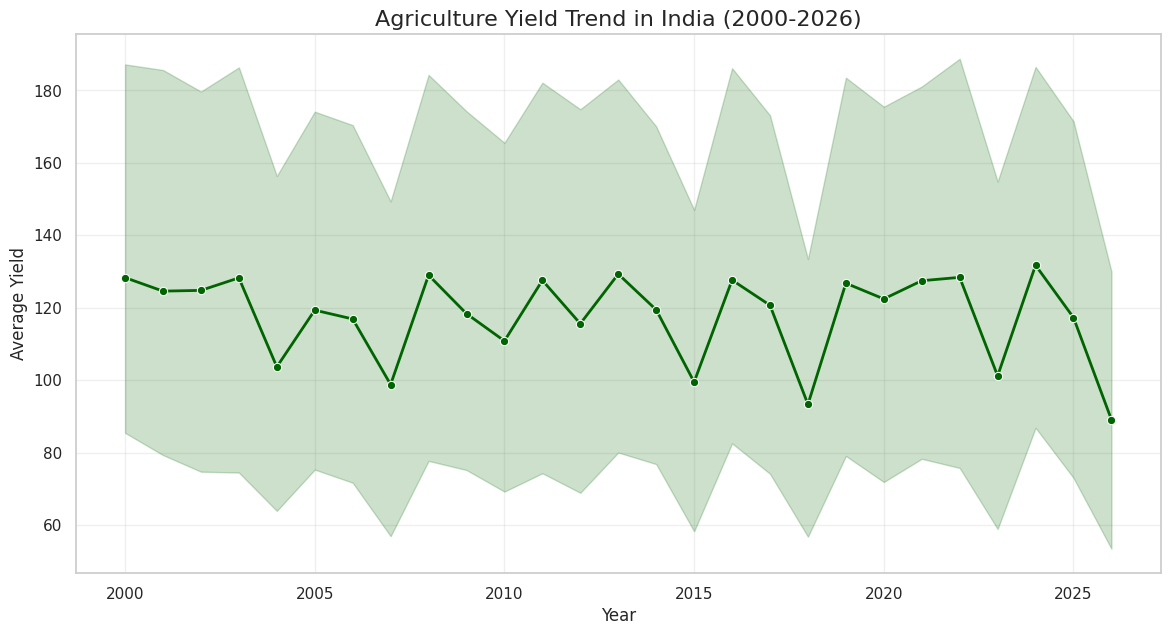

In [50]:
# Saal dar saal yield mein badlav dekhne ke liye
plt.figure(figsize=(14,7))

# Line plot banate hain
sns.lineplot(data=df, x='YEAR', y='AVG_YIELD', marker='o', color='darkgreen', linewidth=2)

plt.title('Agriculture Yield Trend in India (2000-2026)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Yield', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
# Ma'am jo bhi State ya Year bolein, bas niche change karke run kar dein
selected_state = 'Punjab'  # Aap isko 'Haryana' ya 'UP' kar sakte hain
selected_year = 2025       # Aap isko 2000-2026 ke beech badal sakte hain

# Data Filter karna
filtered_df = df[(df['STATE_REGION'] == selected_state) & (df['YEAR'] == selected_year)]

print(f"--- Data for {selected_state} in {selected_year} ---")
display(filtered_df)

KeyError: 'STATE_REGION'

In [54]:
# Isse aapko saare columns ke sahi naam dikh jayenge
print(df.columns)

Index(['ID', 'State_Region', 'YEAR', 'CROP-TYPE', 'SOIL_TYPE', 'SOIL_PH',
       'FERTILIZER(KG/HA)', 'PESTICIDE(KG/HA)', 'AVG_YIELD', 'TEMP', 'RAIN'],
      dtype='object', name=0)


In [ ]:

selected_state = 'Rajasthan'  
selected_year = 2000

filtered_df = df[(df['State_Region'] == selected_state) & (df['YEAR'] == selected_year)]

print(f"--- Data for {selected_state} in {selected_year} ---")

if not filtered_df.empty:
    display(filtered_df)
else:
    print("Ma'am, your data is not found ,please try another state or year.")

: 